# Radius update mechanisms on a closed-form example

`f(x) = e^{-x}` on $[0,\infty)$, where every quantity the trust-region iteration needs is
available in closed form. That makes it the right place to check what a radius rule *does*
against what it is supposed to do.

**Every number and figure below comes from `tr_solve`.** The notebook does not simulate the
mechanisms; it runs them:

```julia
nlp   = ADNLPModel(v -> exp(-v[1]), [0.0])
stats = tr_solve(nlp; rule = RGrad(μ = 0.5), model = ExactHessian(),
                 subsolver = SteihaugCG(), trace = true, params = ...)
Δ = stats.solver_specific[:delta_trajectory]
```

That matters for two reasons. A simulated copy of a rule can drift from the shipped one, and
every figure below the drift still looks healthy. And a simulation tests only the recurrence,
whereas `tr_solve` puts the model, the subproblem solver, the ratio, the acceptance test and
the rule on the line together — so a wrong step or a wrong $\rho$ breaks the closed-form
results just as surely as a wrong branch does.

The closed-form results proved in the text — $\Delta_k \to \ln\gamma_3$, the harmonic decay
$k\Delta_k \to 1$, the $\gamma_3$ versus $e$ dividing line — are therefore **assertions about
the package**, checked on every run. Anything the package gets wrong surfaces as a violated
`@assert` rather than as a slightly odd-looking curve.

What stays hand-written is the *example*: $\rho_{\text{exact}}$, the map $\varphi$, and the
Stolz–Cesàro argument. Those are the analysis this notebook exists to present, and they are
what the package is being checked against.

## Setup

```julia 
using Pkg; Pkg.activate(joinpath(@__DIR__, ".."))
```

To run just once, 
```julia 
Pkg.develop(joinpath(@__DIR__, "..", ".."))
```

```julia
Pkg.add(["ADNLPModels", "Plots", "LaTeXStrings", "Printf"])
```

In [1]:
using Pkg 
Pkg.activate(joinpath(@__DIR__, ".."))

# Pkg.develop(joinpath(@__DIR__, "..", ".."))
# Pkg.add(["ADNLPModels", "Plots", "LaTeXStrings", "Printf"])

  Activating project at `c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\notebooks`


In [2]:
using TrustRegionRadius
using ADNLPModels, NLPModels
using Random, LinearAlgebra
using Plots, LaTeXStrings, Printf

gr()                                   # GR backend: fast, good PDF output
default(fontfamily = "Computer Modern", # match a LaTeX document
        framestyle = :box, grid = true, gridalpha = 0.25,
        legendfontsize = 7, guidefontsize = 9, tickfontsize = 7,
        titlefontsize = 9, linewidth = 1.2, markersize = 2.5, size = (700, 400))

In [3]:
# ---- standard parameters (change these and re-run) -----------------------
const ETA1, ETA2 = 0.1, 0.75        # acceptance / very-successful thresholds
const G1, G2, G3 = 0.25, 0.5, 2.0   # gamma_1, gamma_2, gamma_3
const ZETA       = 0.5              # R-DFO criticality threshold
const MU0, DELTA0 = 0.5, 1.0        # initial mu and radius
const MU_BAR     = 2.0              # cap for the bounded-mu variant of R-grad

println("parameters loaded")

parameters loaded


## The example

$f(x)=e^{-x}$ on $[0,\infty)$: $g(x)=-e^{-x}$, $H(x)=e^{-x}$, so $\|g_k\|=\|H_k\|=e^{-x_k}$.
The model $m_k(s)=(-s+\tfrac12 s^2)e^{-x_k}$ has unconstrained minimiser $s^\ast=1$, hence
$s_k=\min\{1,\Delta_k\}$, and

$$\rho_k(s)=\frac{1-e^{-s}}{s\,(1-s/2)} = 1 + \frac{s^2}{6} + \frac{s^3}{24} + O(s^4) \;\ge\; 1
\quad\text{on } (0,1],$$

so **every iteration is very successful**. The gradient vanishes while $x_k\to+\infty$: no
accumulation point.

This is what makes the example worth having. Because $\rho_k \geq 1 > \eta_2$ always, the
accept/reject machinery is inert and *only* the radius recurrence is exercised — every
difference between the curves below is attributable to the rule and to nothing else.

In [4]:
"Acceptance ratio on the example.  ρ(s) = 1 + s²/6 + s³/24 + O(s⁴) → 1 from above."
ρ_exact(s) = (1 - exp(-s)) / (s * (1 - s/2))

@assert all(ρ_exact.(range(1e-3, 1.0, length = 500)) .>= 1.0) "ρ must be ≥ 1 on (0,1]"
@printf("ρ(0.001) = %.10f    ρ(1) = %.10f\n", ρ_exact(1e-3), ρ_exact(1.0))
println("OK: ρ ≥ 1 > η₂, so every iteration is very successful.")

# The expansion itself, checked rather than asserted in prose. The leading
# coefficient is 1/6:
#     1 − e^{−s} = s(1 − s/2 + s²/6 − s³/24 + …)
#     ρ(s) = (1 − s/2 + s²/6 − …)/(1 − s/2) = 1 + (s²/6 − s³/24 + …)/(1 − s/2)
#          = 1 + s²/6 + s³/24 + O(s⁴)
# The s³ term is POSITIVE, so the expansion approaches 1 from above at both orders.
let
    ρ_approx(s) = 1 + s^2/6 + s^3/24
    println("\ns        ρ(s)          1 + s²/6 + s³/24     error")
    for s in (0.01, 0.05, 0.1, 0.3)
        @printf("%-8.2f %-13.10f %-20.10f %.2e\n", s, ρ_exact(s), ρ_approx(s),
                abs(ρ_exact(s) - ρ_approx(s)))
        # error must be O(s⁴): comfortably below s⁴ with a modest constant
        @assert abs(ρ_exact(s) - ρ_approx(s)) < 0.1 * s^4 "expansion must be correct to O(s⁴)"
    end
    # and the leading coefficient is 1/6, not 1/12 — a factor of two apart, so a
    # coarse test would not separate them.
    s = 1e-4
    @assert isapprox((ρ_exact(s) - 1)/s^2, 1/6; rtol = 1e-3) "leading coefficient is 1/6"
    println("\n✓ ρ(s) = 1 + s²/6 + s³/24 + O(s⁴) verified numerically")
end

ρ(0.001) = 1.0000001667    ρ(1) = 1.2642411177
OK: ρ ≥ 1 > η₂, so every iteration is very successful.

s        ρ(s)          1 + s²/6 + s³/24     error
0.01     1.0000167086  1.0000167083         2.93e-10
0.05     1.0004220615  1.0004218750         1.87e-07
0.10     1.0017113891  1.0017083333         3.06e-06
0.30     1.0163991346  1.0161250000         2.74e-04

✓ ρ(s) = 1 + s²/6 + s³/24 + O(s⁴) verified numerically


## The driver

`tr_solve` runs the example. Nothing about the iteration is reimplemented here — not the
rule, not the subproblem, not the ratio, not the acceptance test:

```julia
nlp = ADNLPModel(v -> exp(-v[1]), [x0])
stats = tr_solve(nlp; rule, model = ExactHessian(), subsolver = SteihaugCG(),
                 params = TRParams(η1 = ETA1, η2 = ETA2, Δ0 = Δ0, ...), trace = true)
```

The pieces line up with the analysis exactly, which is why this example is worth running
through the real solver rather than simulating:

| the analysis says | the solver does |
|:--|:--|
| $H_k = e^{-x_k} > 0$ | `ExactHessian` on a 1-D problem: positive definite |
| $s^\ast = 1$, so $s_k = \min\{1,\Delta_k\}$ | `SteihaugCG` finds the interior Newton point, or truncates at the boundary |
| $\rho_k \ge 1 > \eta_2$ | computed from `ared/pred`, not assumed |

Everything the figures need comes back in `stats.solver_specific`:

- $\Delta_k$ — `:delta_trajectory`
- $\|g_k\|$ — `:grad_trajectory`
- $x_k = -\log\|g_k\|$, since $\|g_k\| = e^{-x_k}$
- $\mu_k = \Delta_k/\|g_k\|$ — the multiplier *is* the radius-to-criticality ratio, so it
  needs no separate record

`tol` is set to `1e-300` so the run never stops early: we want exactly `N` iterations of the
recurrence, not convergence. The status will be `:max_iter`, which here is the intended
outcome rather than a failure.

In [5]:
"""
    run_example(rule; N, x0, Δ0) -> (Δs, gs, xs, μs)

Run `f(x) = exp(-x)` through `tr_solve` and return the trajectories the figures need.

Nothing here reimplements the iteration: the rule, the subproblem solver, the ratio and the
acceptance test all come from the package, and this function only unpacks the trace.

`μs` is `Δ_k / ‖g_k‖`. For `RGrad` and `RGradCapped` that *is* the multiplier by definition;
for the other rules it is a derived ratio with no separate meaning.
"""
function run_example(rule::RadiusRule; N = 30, x0 = 0.0, Δ0 = DELTA0)
    nlp = ADNLPModel(v -> exp(-v[1]), [x0], name = "exp(-x)")
    st  = tr_solve(nlp; rule = rule, model = ExactHessian(), subsolver = SteihaugCG(),
                   params = TRParams(η1 = ETA1, η2 = ETA2, Δ0 = Δ0,
                                     tol = 1e-300, max_iterations = N),
                   trace = true)
    ss = st.solver_specific
    # `max_iterations = N` bounds the run; it does not guarantee it. Three of the
    # five rules below stall before N on this problem, when the radius collapses
    # to where f(x) - f(x+s) is pure rounding: R-delta at 607, R-grad with μ
    # unbounded at 539, R-step at 393. Slicing [1:N] threw a BoundsError on each.
    # Take what the run produced and let the caller see how much that was.
    n  = min(N, length(ss[:delta_trajectory]))
    Δ  = ss[:delta_trajectory][1:n]        # Δ_0 … Δ_{n-1}
    g  = ss[:grad_trajectory][1:n]
    x  = -log.(g)                          # ‖g_k‖ = e^{-x_k}
    μ  = Δ ./ g                            # μ_k = Δ_k / ‖g_k‖
    return Δ, g, x, μ
end

# Factories, so each run starts from a clean multiplier.
mk_delta()      = RDelta(     γ1 = G1, γ2 = G2, γ3 = G3)
mk_step()       = RStep(      γ1 = G1, γ2 = G2, γ3 = G3)
mk_dfo()        = RDFO(       γ1 = G1, γ2 = G2, γ3 = G3, ζ = ZETA)
mk_grad()       = RGrad(      γ1 = G1, γ2 = G2, γ3 = G3, μ = MU0)
mk_gradcapped() = RGradCapped(γ1 = G1, γ2 = G2, γ3 = G3, μ = MU0, μ_max = MU_BAR)

# The solver must reproduce the closed-form step, or nothing below means anything.
let st = tr_solve(ADNLPModel(v -> exp(-v[1]), [0.0]); rule = mk_delta(),
                  params = TRParams(η1 = ETA1, η2 = ETA2, Δ0 = 0.4,
                                    tol = 1e-300, max_iterations = 1), trace = true)
    ss = st.solver_specific
    @assert ss[:step_trajectory][1] ≈ 0.4       "Δ = 0.4 < s* = 1 ⇒ s = Δ (boundary)"
    @assert ss[:active_trajectory][1]           "…and the constraint binds"
    @assert ss[:ratio_trajectory][1] ≈ ρ_exact(0.4) rtol = 1e-8
end
let st = tr_solve(ADNLPModel(v -> exp(-v[1]), [0.0]); rule = mk_delta(),
                  params = TRParams(η1 = ETA1, η2 = ETA2, Δ0 = 2.5,
                                    tol = 1e-300, max_iterations = 1), trace = true)
    ss = st.solver_specific
    @assert ss[:step_trajectory][1] ≈ 1.0       "Δ = 2.5 > s* = 1 ⇒ s = 1 (interior)"
    @assert !ss[:active_trajectory][1]          "…and the constraint does not bind"
    @assert ss[:ratio_trajectory][1] ≈ ρ_exact(1.0) rtol = 1e-8
end
println("✓ the solver reproduces s_k = min(1, Δ_k) and ρ_k = ρ_exact(s_k)")

✓ the solver reproduces s_k = min(1, Δ_k) and ρ_k = ρ_exact(s_k)


### Reference values, asserted against the solver

Hand-checked once, re-checked on every run. These are now statements about the **whole
solver path** — model, subproblem, ratio, acceptance and rule together — not about
`update_radius!` in isolation.

`R-delta` doubles on every (very successful) iteration from $\Delta_0 = 1$, so
$\Delta_{10} = 2^{10} = 1024$ and $\Delta_{29} = 2^{29}$. `R-step` locks onto the unit step:
$s_k = 1$ and $\Delta_{k+1} = \gamma_3\lvert s_k\rvert = 2$.

In [6]:
let
    Δd  = run_example(mk_delta();      N = 30)[1]
    Δst = run_example(mk_step();       N = 30)[1]
    Δf  = run_example(mk_dfo();        N = 30)[1]
    μgb = run_example(mk_gradcapped(); N = 30)[4]

    @assert Δd[11]  ≈ 1024.0       "R-delta Δ₁₀ = γ₃¹⁰ Δ₀"
    @assert Δd[30]  ≈ 536870912.0  "R-delta Δ₂₉ = γ₃²⁹ Δ₀"
    @assert Δst[11] ≈ 2.0          "R-step locks onto γ₃|s| = 2"
    @assert Δst[30] ≈ 2.0          "R-step stays there"
    @assert μgb[end] ≈ MU_BAR rtol = 1e-8  "RGradCapped saturates at μ_max"

    println("✓ reference values reproduced end to end")
    @printf("  R-delta  Δ₁₀ = %.1f        Δ₂₉ = %.6e\n", Δd[11], Δd[30])
    @printf("  R-step   Δ₁₀ = %.6f    Δ₂₉ = %.6f\n", Δst[11], Δst[30])
    @printf("  R-DFO    Δ₁₀ = %.6f    Δ₂₉ = %.6f\n", Δf[11], Δf[30])
    @printf("  R-grad capped: μ = Δ/‖g‖ saturated at %.6f\n", μgb[end])
end

✓ reference values reproduced end to end
  R-delta  Δ₁₀ = 1024.0        Δ₂₉ = 5.368709e+08
  R-step   Δ₁₀ = 2.000000    Δ₂₉ = 2.000000
  R-DFO    Δ₁₀ = 0.062500    Δ₂₉ = 0.031250
  R-grad capped: μ = Δ/‖g‖ saturated at 2.000000


In [7]:
const LBL_GB = L"R-grad ($\mu$ bounded)"
const LBL_GU = L"R-grad ($\mu$ unbounded)"

N = 30
sim = Dict(
    "R-delta" => run_example(mk_delta();      N = N),
    "R-step"  => run_example(mk_step();       N = N),
    "R-DFO"   => run_example(mk_dfo();        N = N),
    "gb"      => run_example(mk_gradcapped(); N = N),
    "gu"      => run_example(mk_grad();       N = N),
)

@printf("%-24s %8s %12s %13s   %s\n", "rule", "Δ₀", "Δ₁₀", "Δ₂₉", "regime")
for (key, name) in [("R-delta","R-delta"), ("R-step","R-step"), ("R-DFO","R-DFO"),
                    ("gb","R-grad (μ bounded)"), ("gu","R-grad (μ unbounded)")]
    Δ, g, x, μ = sim[key]
    rule = key == "R-delta" ? mk_delta() : key == "R-step" ? mk_step() :
           key == "R-DFO"   ? mk_dfo()   : key == "gb"     ? mk_gradcapped() : mk_grad()
    @printf("%-24s %8.3f %12.4e %13.4e   %s\n",
            name, Δ[1], Δ[11], Δ[end], asymptotic_regime(rule))
end
println()
println("The `regime` column is the package's own classification, asymptotic_regime(rule).")
println("It is what the experiment scripts group by, and it should match what the curves do.")

rule                           Δ₀          Δ₁₀           Δ₂₉   regime
R-delta                     1.000   1.0240e+03    5.3687e+08   bounded_below
R-step                      1.000   2.0000e+00    2.0000e+00   step_summable
R-DFO                       1.000   6.2500e-02    3.1250e-02   vanishing
R-grad (μ bounded)          0.500   9.4134e-02    3.3161e-02   vanishing
R-grad (μ unbounded)        0.500   6.9314e-01    6.9315e-01   vanishing

The `regime` column is the package's own classification, asymptotic_regime(rule).
It is what the experiment scripts group by, and it should match what the curves do.


## Figure 1 — all five mechanisms

R-delta expands geometrically; R-step locks onto the unit step at $\Delta_k=2$; R-DFO and R-grad
($\mu$ bounded) decay; R-grad ($\mu$ unbounded) plateaus at $\ln\gamma_3$ — the coefficient
$\mu_k=\gamma_3^k\mu_0$ diverges and the radius has *detached* from the criticality measure.

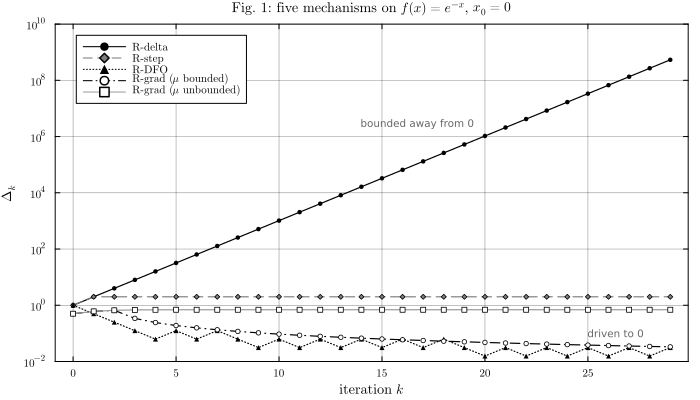

In [8]:
ks = 0:N-1
p1 = plot(xlabel = L"iteration $k$", ylabel = L"\Delta_k", yscale = :log10,
          legend = :topleft , title = L"Fig. 1: five mechanisms on $f(x)=e^{-x}$, $x_0=0$",
          ylims = (1e-2, 1e10))
plot!(p1, ks, sim["R-delta"][1], label = "R-delta",  c = :black, ls = :solid,   m = :circle)
plot!(p1, ks, sim["R-step"][1],  label = "R-step",   c = :gray50, ls = :dash,   m = :diamond)
plot!(p1, ks, sim["R-DFO"][1],   label = "R-DFO",    c = :black, ls = :dot,     m = :utriangle)
plot!(p1, ks, sim["gb"][1],      label = LBL_GB,     c = :black, ls = :dashdot, m = :circle,
      markerstrokecolor = :black, markercolor = :white)
plot!(p1, ks, sim["gu"][1],      label = LBL_GU,     c = :gray60, ls = :solid,  m = :square,
      markercolor = :white)
annotate!(p1, 14, 3e6,  text("bounded away from 0", 7, :gray40, :left))
annotate!(p1, 25, 0.1, text("driven to 0", 7, :gray40, :left))
savefig(p1, "fig1_all_mechanisms.pdf"); savefig(p1, "fig1_all_mechanisms.png")
p1

## Figure 2 — the criticality-anchored variants

R-DFO's **sawtooth is genuine**: the test $\Delta_k \lessgtr \zeta\|g_k\|$ alternately expands and
contracts the radius as it tracks the gradient. With $\mu$ bounded, R-grad decays smoothly; with
$\mu$ unbounded it stalls exactly at $\ln\gamma_3$, so $\mu_k\le\overline\mu$ is the dividing line
between the regimes, not a technicality.

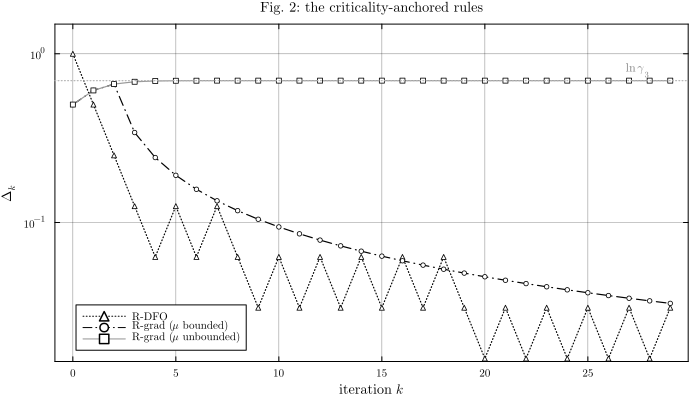

In [9]:
p2 = plot(xlabel = L"iteration $k$", ylabel = L"\Delta_k", yscale = :log10,
          legend = :bottomleft, title = "Fig. 2: the criticality-anchored rules",
          ylims = (1.5e-2, 1.5))
plot!(p2, ks, sim["R-DFO"][1], label = "R-DFO", c = :black, ls = :dot, m = :utriangle,
      markercolor = :white)
plot!(p2, ks, sim["gb"][1],    label = LBL_GB,  c = :black, ls = :dashdot, m = :circle,
      markercolor = :white)
plot!(p2, ks, sim["gu"][1],    label = LBL_GU,  c = :gray60, ls = :solid, m = :square,
      markercolor = :white)
hline!(p2, [log(G3)], label = "", c = :gray70, ls = :dot)
annotate!(p2, N-2, log(G3)*1.15, text(L"\ln\gamma_3", 8, :gray50, :right))
savefig(p2, "fig2_anchored.pdf"); savefig(p2, "fig2_anchored.png")
p2

## Figure 3 — R-step and R-delta on a strongly convex example

Figures 1–2 are the **global** regime, where the iterates have no accumulation point. For R-step the
picture reverses once $x_k\to x^\ast$ with $\nabla^2 f(x^\ast)\succ0$.

Take $f(x)=\tfrac12 x^2$, $x^\ast=0$, with model Hessian $H_k=c>1$ over-estimating the curvature. The
step is $s_k=-x_k/c$, so $x_{k+1}=(1-1/c)x_k$: linear convergence with geometrically shrinking steps.
Powell's summability $\sum_k\|s_k\|<\infty$ then propagates to the radius through
$\Delta_{k+1}=\gamma_3\|s_k\|$.

**R-step is not intrinsically a "radius bounded below" rule.** Here it drives $\Delta_k\to0$
*geometrically*, with $\sum_k\Delta_k<\infty$ — which is why the package classifies it
`:step_summable` rather than `:bounded_below`. The three-valued `asymptotic_regime` exists to
express this middle case; the older two-valued `is_criticality_anchored` cannot, and it is the
case that separates `RStep` from `RDelta`.

No custom driver is needed for this either: **`ScaledIdentity(c = 4.0)` *is* the model
$H_k = c$**, and it is in the package precisely so that the model can be held fixed while the
radius rule varies. Its docstring puts it exactly this way — with it the step is $-g/c$
truncated to the region, so any difference between radius rules is attributable to the rule
alone.

This run also exercises the accept/reject path, which the $e^{-x}$ example never does: there
$\rho_k \ge 1$ always, here it is not.

In [10]:
"""
    run_strongly_convex(rule; c, N, x0, Δ0) -> (Δs, ss)

Local regime: `f(x) = x²/2` (strongly convex, x* = 0) with the model Hessian held at
`H_k = c > 1` by `ScaledIdentity`. As above, `tr_solve` does the iterating.
"""
function run_strongly_convex(rule::RadiusRule; c = 4.0, N = 40, x0 = 1.0, Δ0 = 2.0)
    nlp = ADNLPModel(v -> 0.5 * v[1]^2, [x0], name = "x²/2")
    st  = tr_solve(nlp; rule = rule, model = ScaledIdentity(c = c),
                   subsolver = SteihaugCG(),
                   params = TRParams(η1 = ETA1, η2 = ETA2, Δ0 = Δ0,
                                     tol = 1e-300, max_iterations = N),
                   trace = true)
    ss = st.solver_specific
    # `min(N, end)` on both. It was already written that way for the step and
    # not for the radius, so `N = 300` threw on a run that stalls at 91.
    return ss[:delta_trajectory][1:min(N, end)], ss[:step_trajectory][1:min(N, end)]
end

const C_HESS = 4.0
loc_step,  _ = run_strongly_convex(mk_step();  c = C_HESS)
loc_delta, _ = run_strongly_convex(mk_delta(); c = C_HESS)

@assert isapprox(loc_step[6]/loc_step[5], 1 - 1/C_HESS; rtol = 1e-8) "R-step ratio = 1 - 1/c"
@assert isapprox(sum(run_strongly_convex(mk_step(); c = C_HESS, N = 300)[1]), 4.0; rtol = 1e-6)
@assert asymptotic_regime(mk_step())  === :step_summable
@assert asymptotic_regime(mk_delta()) === :bounded_below
println("✓ strongly convex assertions passed; the package's own regime labels agree")

@printf("\nStrongly convex: H_k = %.1f (true Hessian 1), contraction 1 - 1/c = %.4f\n",
        C_HESS, 1 - 1/C_HESS)
@printf("%4s %14s %10s | %14s\n", "k", "R-step Δ_k", "ratio", "R-delta Δ_k")
for k in [5, 10, 15, 20, 25]
    @printf("%4d %14.4e %10.6f | %14.4e\n", k, loc_step[k+1],
            loc_step[k+1]/loc_step[k], loc_delta[k+1])
end
@printf("\nΣ Δ_k over 300 iterations, R-step = %.4f   (FINITE: the sharper rate)\n",
        sum(run_strongly_convex(mk_step(); c = C_HESS, N = 300)[1]))

✓ strongly convex assertions passed; the package's own regime labels agree

Strongly convex: H_k = 4.0 (true Hessian 1), contraction 1 - 1/c = 0.7500
   k     R-step Δ_k      ratio |    R-delta Δ_k
   5     1.5820e-01   0.750000 |     6.4000e+01
  10     3.7542e-02   0.750000 |     2.0480e+03
  15     8.9090e-03   0.750000 |     6.5536e+04
  20     2.1141e-03   0.750000 |     2.0972e+06
  25     5.0170e-04   0.750000 |     6.7109e+07

Σ Δ_k over 300 iterations, R-step = 4.0000   (FINITE: the sharper rate)


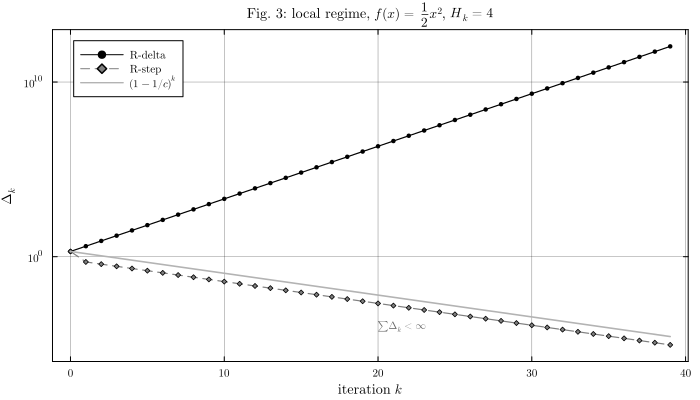

In [11]:
kk = 0:length(loc_delta)-1
p3 = plot(xlabel = L"iteration $k$", ylabel = L"\Delta_k", yscale = :log10,
          legend = :topleft,
          title = L"Fig. 3: local regime, $f(x)=\frac{1}{2}x^2$, $H_k=4$",
          ylims = (1e-6, 1e13))
plot!(p3, kk, loc_delta, label = "R-delta", c = :black,  ls = :solid, m = :circle)
plot!(p3, kk, loc_step,  label = "R-step",  c = :gray50, ls = :dash,  m = :diamond)
plot!(p3, kk, loc_step[1] .* (1 - 1/C_HESS) .^ kk, label = L"(1-1/c)^k",
      c = :gray70, ls = :solid, m = :none, lw = 1.6)
annotate!(p3, 20, 1e-4, text(L"\sum \Delta_k < \infty", 7, :gray40, :left))
savefig(p3, "fig3_strongly_convex.pdf"); savefig(p3, "fig3_strongly_convex.png")
p3

## The decay rate: $\Delta_k=\Theta(1/k)$

A natural guess is that $\Delta_k$ inherits the *exponential* decay of $\|g_k\|=e^{-x_k}$. It does
not. Once $\Delta_k\le1$ we have $s_k=\Delta_k$, so the iterates advance by exactly the radius,
$x_{k+1}=x_k+\Delta_k$, and with $\Delta_k=\overline\mu\,e^{-x_k}$ this gives the **exact autonomous
recursion**

$$\Delta_{k+1} = \overline\mu\,e^{-x_k}e^{-\Delta_k} = \Delta_k\,e^{-\Delta_k}.$$

Setting $v_k=1/\Delta_k$ gives $v_{k+1}-v_k = v_k(e^{1/v_k}-1) = 1+\tfrac{1}{2v_k}+O(v_k^{-2})\to1$,
so by Stolz–Cesàro $v_k/k\to1$, that is $\boxed{\lim_k k\,\Delta_k = 1}$.

The radius decays **harmonically**: $\sum_k\Delta_k\sim\sum 1/k=\infty$ while
$\sum_k\Delta_k^2\sim\sum 1/k^2<\infty$.

In [12]:
const NL = 400
Δ_dfo  = run_example(mk_dfo();        N = NL)[1]
Δ_grad = run_example(mk_gradcapped(); N = NL)[1]

println("Check of the exact recursion  Δ_{k+1} = Δ_k exp(-Δ_k)   (R-grad, μ saturated):")
for k in [50, 100, 200, 300]
    pred = Δ_grad[k+1] * exp(-Δ_grad[k+1])
    @printf("  k=%3d:  Δ_k = %.10f   Δ_(k+1) = %.10f   predicted = %.10f   |err| = %.2e\n",
            k, Δ_grad[k+1], Δ_grad[k+2], pred, abs(Δ_grad[k+2] - pred))
    @assert isapprox(Δ_grad[k+2], pred; rtol = 1e-10) "exact recursion must hold"
end
println("\n✓ the recursion is exact to ten digits.")
println("  This is a statement about the SOLVER: Δ_grad comes out of tr_solve — model,")
println("  subproblem, ratio, acceptance and rule — and reproduces a recurrence derived")
println("  on paper. A wrong step, a wrong ρ or a wrong branch would all break it.")

Check of the exact recursion  Δ_{k+1} = Δ_k exp(-Δ_k)   (R-grad, μ saturated):
  k= 50:  Δ_k = 0.0194459141   Δ_(k+1) = 0.0190714234   predicted = 0.0190714234   |err| = 1.04e-17
  k=100:  Δ_k = 0.0098263109   Δ_(k+1) = 0.0097302273   predicted = 0.0097302273   |err| = 3.47e-18
  k=200:  Δ_k = 0.0049477646   Δ_(k+1) = 0.0049233447   predicted = 0.0049233447   |err| = 1.73e-18
  k=300:  Δ_k = 0.0033078292   Δ_(k+1) = 0.0032969055   predicted = 0.0032969055   |err| = 4.34e-19

✓ the recursion is exact to ten digits.
  This is a statement about the SOLVER: Δ_grad comes out of tr_solve — model,
  subproblem, ratio, acceptance and rule — and reproduces a recurrence derived
  on paper. A wrong step, a wrong ρ or a wrong branch would all break it.


## Figure 4 — the $1/k$ decay

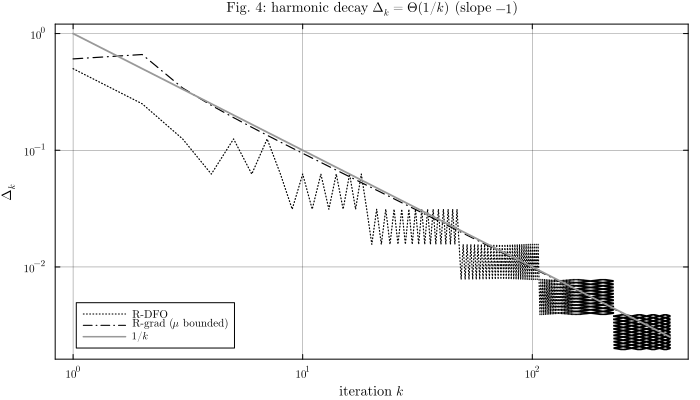

In [13]:
idx = 1:NL-1
p4 = plot(xlabel = L"iteration $k$", ylabel = L"\Delta_k",
          xscale = :log10, yscale = :log10, legend = :bottomleft,
          title = L"Fig. 4: harmonic decay $\Delta_k=\Theta(1/k)$ (slope $-1$)")
plot!(p4, idx, Δ_dfo[2:NL],  label = "R-DFO", c = :black, ls = :dot,     m = :none)
plot!(p4, idx, Δ_grad[2:NL], label = LBL_GB,  c = :black, ls = :dashdot, m = :none)
plot!(p4, idx, 1 ./ idx,     label = L"1/k",  c = :gray60, ls = :solid,  m = :none, lw = 1.8)
savefig(p4, "fig4_decay_1_over_k.pdf"); savefig(p4, "fig4_decay_1_over_k.png")
p4

## Figure 5 — $k\,\Delta_k\to1$

For **R-grad** the limit is exactly $1$, as Stolz–Cesàro predicts. For **R-DFO** the sawtooth
prevents convergence to a constant, but the product stays within a fixed band: $\Theta(1/k)$ there
too.

    k    R-grad: k·Δ_k    R-DFO: k·Δ_k
   10         0.941342        0.625000
   50         0.972296        0.781250
  100         0.982631        1.562500
  200         0.989553        0.781250
  399         0.993885        0.779297

✓ R-grad reaches 0.9939 at k=399, confirming the Stolz–Cesàro limit.


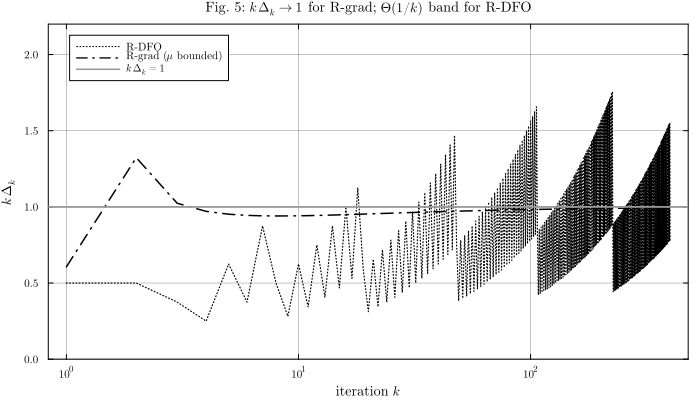

In [14]:
p5 = plot(xlabel = L"iteration $k$", ylabel = L"k\,\Delta_k", xscale = :log10,
          legend = :topleft, ylims = (0, 2.2),
          title = L"Fig. 5: $k\,\Delta_k \to 1$ for R-grad; $\Theta(1/k)$ band for R-DFO")
plot!(p5, idx, idx .* Δ_dfo[2:NL],  label = "R-DFO", c = :black, ls = :dot)
plot!(p5, idx, idx .* Δ_grad[2:NL], label = LBL_GB, c = :black, ls = :dashdot, lw = 1.5)
hline!(p5, [1.0], label = L"k\,\Delta_k = 1", c = :gray60, lw = 1.8)
savefig(p5, "fig5_k_times_delta.pdf"); savefig(p5, "fig5_k_times_delta.png")

@printf("%5s %16s %15s\n", "k", "R-grad: k·Δ_k", "R-DFO: k·Δ_k")
for k in [10, 50, 100, 200, 399]
    @printf("%5d %16.6f %15.6f\n", k, k*Δ_grad[k+1], k*Δ_dfo[k+1])
end
@assert isapprox(399*Δ_grad[400], 0.993885; atol = 1e-5) "k·Δ_k → 1"
println("\n✓ R-grad reaches 0.9939 at k=399, confirming the Stolz–Cesàro limit.")
p5

## LaTeX table export

The two tables below are written **straight to disk** as plain `.txt` files, ready to open and paste
into the article. Because they are regenerated on every run of this notebook, the numbers in the
text can never drift out of sync with the figures.

Files produced: `tab_gamma3_robustness.txt`, `tab_sums.txt`.

> Both tables use `booktabs`, so the article preamble needs `\usepackage{booktabs}`. If you would
> rather pull them in automatically than paste, change the extension back to `.tex` and use
> `\input{tab_sums}`.

In [15]:
"""
    latex_table(io, header, rows; caption, label, align, note)

Write a `booktabs` table to `io`.  `rows` is a vector of vectors of already-formatted
strings.  Pass `stdout` to preview, or use `open(io -> latex_table(io, ...), path, "w")`
to write a standalone file for `input`.
"""
function latex_table(io::IO, header, rows; caption = "", label = "", align = "", note = "")
    align = isempty(align) ? "l" * "r"^(length(header) - 1) : align
    println(io, "\\begin{table}[htbp]")
    println(io, "  \\centering")
    isempty(caption) || println(io, "  \\caption{", caption, "}")
    isempty(label)   || println(io, "  \\label{", label, "}")
    println(io, "  \\begin{tabular}{", align, "}")
    println(io, "    \\toprule")
    println(io, "    ", join(header, " & "), " \\\\")
    println(io, "    \\midrule")
    for r in rows
        println(io, "    ", join(r, " & "), " \\\\")
    end
    println(io, "    \\bottomrule")
    println(io, "  \\end{tabular}")
    isempty(note) || println(io, "  \\\\[2pt] \\footnotesize ", note)
    println(io, "\\end{table}")
    return nothing
end

# convenience: default to stdout for a quick preview
latex_table(header, rows; kwargs...) = latex_table(stdout, header, rows; kwargs...)

"Format `x` in LaTeX scientific notation with `d` significant decimals."
function sci(x; d = 4)
    isinf(x) && return "\$" * (x > 0 ? "+" : "-") * "\\infty\$"
    isnan(x) && return "---"
    x == 0 && return "\$0\$"
    e = floor(Int, log10(abs(x)))
    m = x / 10.0^e
    return @sprintf("\$%.*f\\times10^{%d}\$", d, m, e)
end

"Format `x` as a plain fixed-point math cell."
fix(x; d = 3) = @sprintf("\$%.*f\$", d, x)

println("LaTeX table helpers loaded (latex_table, sci, fix)")

LaTeX table helpers loaded (latex_table, sci, fix)


## Robustness: the $\gamma_3$ versus $e$ dividing line

The picture does not depend on the parameters, in the following sense — and this is the
sharpest package check in the notebook, because the boundary at $\gamma_3 = e$ is a
*consequence* of the four-branch form of `RGrad`, not something anyone coded deliberately.

With $\mu$ unbounded and every iteration very successful, the recurrence is

$$\varphi(\Delta) = \begin{cases}
\Delta\,e^{\ln\gamma_3 - \min\{1,\Delta\}}, & \Delta < 2 \quad(\text{branch 3 fires}),\\[2pt]
\Delta\,e^{-1}, & \Delta \ge 2 \quad(\text{branch 4: } \mu \text{ unchanged}).
\end{cases}$$

The split at $\Delta = 2$ **is** the half-test guard $\|s_k\| > \tfrac12\Delta_k$: with
$s_k = \min\{1,\Delta_k\}$ that inequality holds exactly when $\Delta_k < 2$. So `half_test`
is what puts the kink there, and the cells below verify that the package's `update_radius!`
reproduces $\varphi$ to machine precision — including the branch nobody usually reaches.

In [16]:
# The map φ, derived on paper, versus what tr_solve actually produces.
φ(Δ, γ3) = Δ ≥ 2 ? Δ * exp(-1) : Δ * exp(log(γ3) - min(1.0, Δ))

println("φ (on paper) versus consecutive Δ_k from tr_solve (RGrad, μ unbounded)\n")
@printf("%8s %10s %14s %14s %12s\n", "γ₃", "crossings", "max rel err", "min Δ", "max Δ")
println("-"^62)
worst_all = 0.0
for γ3 in (1.5, 2.0, ℯ, 3.0, 5.0)
    Δ = run_example(RGrad(γ1 = G1, γ2 = G2, γ3 = γ3, μ = MU0); N = 60, Δ0 = 3.0)[1]
    errs = [abs(Δ[k+1] - φ(Δ[k], γ3)) / max(φ(Δ[k], γ3), 1e-300) for k in 1:length(Δ)-1]
    cross = count(k -> (Δ[k] - 2) * (Δ[k+1] - 2) < 0, 1:length(Δ)-1)
    worst_all = max(worst_all, maximum(errs))
    @printf("%8.4f %10d %14.3e %14.6f %12.6f\n",
            γ3, cross, maximum(errs), minimum(Δ), maximum(Δ))
end
@assert worst_all < 1e-10 "tr_solve must realise exactly the map the analysis assumes"
println("\n✓ every trajectory follows φ, on both sides of the Δ = 2 branch boundary")
println("  (the `crossings` column confirms the runs actually visit both branches —")
println("   an agreement that never leaves one branch would prove nothing about the other)")

# The split at Δ = 2 IS the half-test guard ‖s‖ > ½Δ: with s = min(1,Δ) that holds
# exactly when Δ < 2. Turn the guard off and the expansion branch fires above 2 too.
let Δ = 2.5, s = 1.0, ρ = ρ_exact(s)
    on  = update_radius!(RGrad(γ1=G1, γ2=G2, γ3=3.0, μ=2.5, half_test=true),
                         Δ, ρ, true, ETA1, ETA2, s, 1.0, exp(-1))
    off = update_radius!(RGrad(γ1=G1, γ2=G2, γ3=3.0, μ=2.5, half_test=false),
                         Δ, ρ, true, ETA1, ETA2, s, 1.0, exp(-1))
    @printf("\nat Δ = 2.5 (> 2, so the guard blocks expansion):\n")
    @printf("  half_test = true  → Δ' = %.6f   (μ held: branch 4)\n", on)
    @printf("  half_test = false → Δ' = %.6f   (μ expanded: guard removed)\n", off)
    @assert on < off "the half-test must suppress expansion above Δ = 2"
end

φ (on paper) versus consecutive Δ_k from tr_solve (RGrad, μ unbounded)

      γ₃  crossings    max rel err          min Δ        max Δ
--------------------------------------------------------------
  1.5000          0      1.643e-15       0.405465     0.500000
  2.0000          0      3.524e-15       0.500000     0.693147
  2.7183          0      9.992e-16       0.500000     1.000000
  3.0000         12      3.405e-15       0.500000     2.191459
  5.0000         46      2.946e-15       0.500000     3.471561

✓ every trajectory follows φ, on both sides of the Δ = 2 branch boundary
  (the `crossings` column confirms the runs actually visit both branches —
   an agreement that never leaves one branch would prove nothing about the other)

at Δ = 2.5 (> 2, so the guard blocks expansion):
  half_test = true  → Δ' = 0.919699   (μ held: branch 4)
  half_test = false → Δ' = 2.759096   (μ expanded: guard removed)


In [17]:
const Γ3_LIST = [1.5, 2.0, 2.5, ℯ, 3.0, 5.0]
const Γ3_LAB  = [L"\gamma_3 = 1.5", L"\gamma_3 = 2", L"\gamma_3 = 2.5",
                 L"\gamma_3 = e", L"\gamma_3 = 3", L"\gamma_3 = 5"]
const Γ3_STY  = [:solid, :dash, :dot, :solid, :dashdot, :dash]
const Γ3_COL  = [:black, :gray40, :gray55, :red, :gray25, :gray70]
const Γ3_LW   = [1.2, 1.2, 1.2, 2.0, 1.2, 1.2]   # highlight the boundary case γ₃ = e

6-element Vector{Float64}:
 1.2
 1.2
 1.2
 2.0
 1.2
 1.2

Effect of γ₃ on R-grad with μ UNBOUNDED: the dividing line is γ₃ vs e = 2.71828
      γ₃    ln γ₃      max Δ    liminf Δ   branch-4 fired
  1.5000    0.405     0.5000      0.4055                0
  2.0000    0.693     0.6931      0.6931                0
  2.5000    0.916     0.9163      0.9163                0
  2.7183    1.000     1.0000      1.0000                0
  3.0000    1.099     2.1915      0.7896                3
  5.0000    1.609     3.4716      0.8283               11

→ γ₃ <  e : the radius never reaches 2, branch 4 never fires, μ_k = γ₃^k μ₀,
            and Δ_k settles at the fixed point ln(γ₃).
→ γ₃ ≥  e : the radius crosses 2, branch 4 fires, μ stalls, liminf Δ_k ≥ 2/e.

✓ wrote fig5a_gamma3_delta.pdf and fig5b_gamma3_mu.pdf

✓ wrote tab_gamma3_robustness.txt


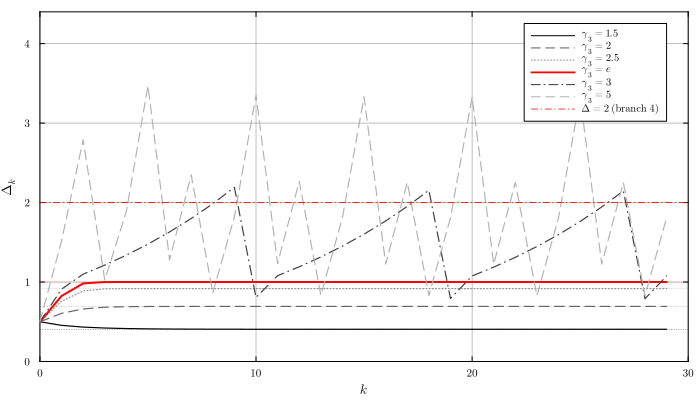

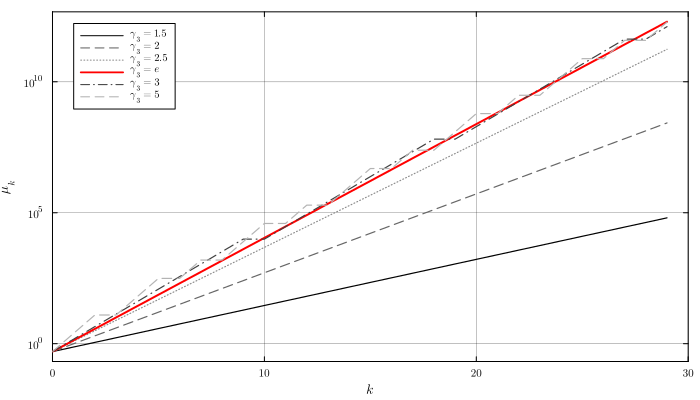

In [18]:
println("Effect of γ₃ on R-grad with μ UNBOUNDED: the dividing line is γ₃ vs e = ", round(ℯ, digits=5))
@printf("%8s %8s %10s %11s %16s\n", "γ₃", "ln γ₃", "max Δ", "liminf Δ", "branch-4 fired")

γ3_rows = Vector{String}[]
Δ_traj  = Vector{Vector{Float64}}()
μ_traj  = Vector{Vector{Float64}}()

N_sim = 30

for γ3 in Γ3_LIST
    Δ, g, x, μ = run_example(RGrad(γ1 = G1, γ2 = G2, γ3 = γ3, μ = MU0); N = N_sim)
    @printf("%8.4f %8.3f %10.4f %11.4f %16d\n",
            γ3, log(γ3), maximum(Δ), minimum(Δ[11:end]), count(≥(2.0), Δ))
    push!(γ3_rows, [fix(γ3; d = 4), fix(log(γ3)), fix(maximum(Δ); d = 4),
                    fix(minimum(Δ[11:end]); d = 4), string(count(≥(2.0), Δ))])
    push!(Δ_traj, Δ)
    push!(μ_traj, μ)
end
println("\n→ γ₃ <  e : the radius never reaches 2, branch 4 never fires, μ_k = γ₃^k μ₀,")
println("            and Δ_k settles at the fixed point ln(γ₃).")
println("→ γ₃ ≥  e : the radius crosses 2, branch 4 fires, μ stalls, liminf Δ_k ≥ 2/e.")

# ---------- plot 1: radius trajectories ----------
pΔ = plot(xlabel = L"k", ylabel = L"\Delta_k", legend = :topright, title = "")
for (i, Δ) in enumerate(Δ_traj)
    plot!(pΔ, 0:length(Δ)-1, Δ; label = Γ3_LAB[i], linestyle = Γ3_STY[i],
          color = Γ3_COL[i], linewidth = Γ3_LW[i])
end
# fixed points ln(γ₃) for the sub-critical settings
for (i, γ3) in enumerate(Γ3_LIST)
    γ3 < ℯ && hline!(pΔ, [log(γ3)]; color = Γ3_COL[i], linestyle = :dot,
                     linewidth = 0.6, alpha = 0.5, label = "")
end
hline!(pΔ, [2.0]; color = :red, linestyle = :dashdot, linewidth = 0.8,
       label = L"\Delta = 2\ \mathrm{(branch\ 4)}")
plot!(pΔ, xlims = (0, N_sim), ylims = (0, 4.4))

# ---------- plot 2: multiplier trajectories ----------
pμ = plot(xlabel = L"k", ylabel = L"\mu_k", yscale = :log10,
          legend = :topleft, title = "")
for (i, μ) in enumerate(μ_traj)
    plot!(pμ, 0:length(μ)-1, μ; label = Γ3_LAB[i], linestyle = Γ3_STY[i],
          color = Γ3_COL[i], linewidth = Γ3_LW[i])
end
plot!(pμ, xlims = (0, N_sim))

display(pΔ); display(pμ)
savefig(pΔ, "fig5a_gamma3_delta.pdf")
savefig(pμ, "fig5b_gamma3_mu.pdf")
println("\n✓ wrote fig5a_gamma3_delta.pdf and fig5b_gamma3_mu.pdf")

open(io -> latex_table(io, [raw"$\gamma_3$", raw"$\ln\gamma_3$", raw"$\max_k\Delta_k$",
                            raw"$\liminf_k\Delta_k$", "branch-4 fired"], γ3_rows;
                       align   = "rrrrr",
                       caption = raw"Effect of $\gamma_3$ on R-grad with $\mu$ unbounded " *
                                 raw"($N=" * string(N_sim) * raw"$ iterations, $f(x)=e^{-x}$, $x_0=0$). The dividing " *
                                 raw"line is $\gamma_3$ versus $e\approx2.71828$: for " *
                                 raw"$\gamma_3<e$ the radius never reaches the unconstrained " *
                                 raw"Newton step, branch~4 never fires, $\mu_k=\gamma_3^k\mu_0$ " *
                                 raw"diverges, and $\Delta_k$ settles at the fixed point " *
                                 raw"$\ln\gamma_3$; for $\gamma_3\ge e$ branch~4 fires, $\mu$ " *
                                 raw"stalls, and $\liminf_k\Delta_k\ge2/e$.",
                       label   = "tab: gamma3 robustness"),
     "tab_gamma3_robustness.txt", "w")

println("\n✓ wrote tab_gamma3_robustness.txt")

Effect of γ₃ on R-grad with μ UNBOUNDED, Δ₀ = 3.0 (above the threshold Δ = 2); dividing line is γ₃ vs e = 2.71828
      γ₃    ln γ₃         Δ₀      max Δ    liminf Δ  expansion fired
  1.5000    0.405     3.0000     3.0000      0.4056                1
  2.0000    0.693     3.0000     3.0000      0.6931                1
  2.5000    0.916     3.0000     3.0000      0.9163                1
  2.7183    1.000     3.0000     3.0000      1.1036                1
  3.0000    1.099     3.0000     3.0000      1.0809                2
  5.0000    1.609     3.0000     3.3251      0.8250                7

Δ₀ > 2: the expansion branch fires once at k = 0 for every γ₃.
→ γ₃ ≤ e : the radius falls below 2 and never returns; μ_k grows like γ₃^k thereafter,
           and Δ_k settles at the fixed point ln(γ₃).
→ γ₃ > e : the radius keeps crossing 2, the branch fires repeatedly, μ stalls,
           and liminf Δ_k ≥ 2/e.

✓ wrote fig5a_gamma3_delta_D0_3p0.pdf and fig5b_gamma3_mu_D0_3p0.pdf
✓ wrote tab_gamm

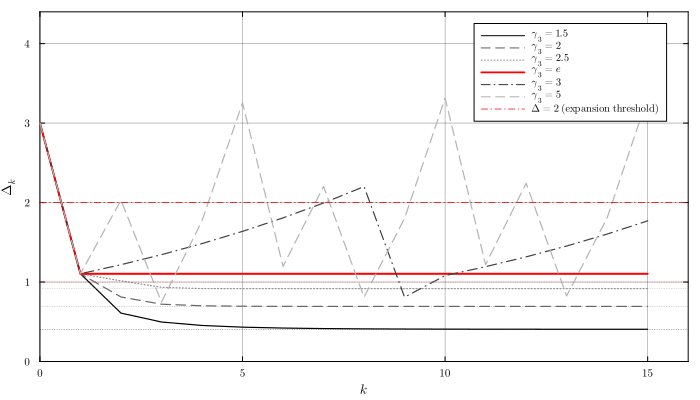

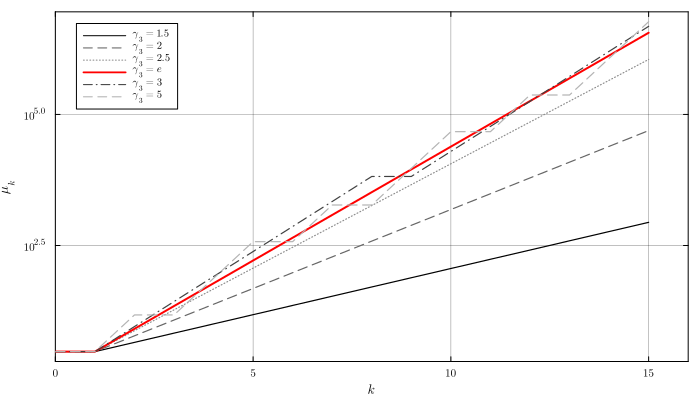

In [19]:
# ---------------------------------------------------------------
# Initial radius: set Δ₀ > 2 to start ABOVE the expansion threshold
# ---------------------------------------------------------------
N_sim = 16
Δ0_sim = 3.0                      # try 0.5 (below) vs 3.0 (above the threshold)

above = Δ0_sim > 2.0
pos   = above ? "above" : "below"

println("Effect of γ₃ on R-grad with μ UNBOUNDED, Δ₀ = ", Δ0_sim,
        " (", pos, " the threshold Δ = 2); dividing line is γ₃ vs e = ", round(ℯ, digits = 5))
@printf("%8s %8s %10s %10s %11s %16s\n",
        "γ₃", "ln γ₃", "Δ₀", "max Δ", "liminf Δ", "expansion fired")

γ3_rows = Vector{String}[]
Δ_traj  = Vector{Vector{Float64}}()
μ_traj  = Vector{Vector{Float64}}()

for γ3 in Γ3_LIST
    Δ, g, x, μ = run_example(RGrad(γ1 = G1, γ2 = G2, γ3 = γ3, μ = Δ0_sim); N = N_sim, Δ0 = Δ0_sim)
    lo = minimum(Δ[min(11, end):end])
    @printf("%8.4f %8.3f %10.4f %10.4f %11.4f %16d\n",
            γ3, log(γ3), Δ[1], maximum(Δ), lo, count(≥(2.0), Δ))
    push!(γ3_rows, [fix(γ3; d = 4), fix(log(γ3)), fix(maximum(Δ); d = 4),
                    fix(lo; d = 4), string(count(≥(2.0), Δ))])
    push!(Δ_traj, Δ); push!(μ_traj, μ)
end

if above
    println("\nΔ₀ > 2: the expansion branch fires once at k = 0 for every γ₃.")
    println("→ γ₃ ≤ e : the radius falls below 2 and never returns; μ_k grows like γ₃^k thereafter,")
    println("           and Δ_k settles at the fixed point ln(γ₃).")
    println("→ γ₃ > e : the radius keeps crossing 2, the branch fires repeatedly, μ stalls,")
    println("           and liminf Δ_k ≥ 2/e.")
else
    println("\nΔ₀ < 2: the expansion branch never fires for γ₃ ≤ e.")
    println("→ γ₃ ≤ e : μ_k = γ₃^k μ₀ and Δ_k settles at the fixed point ln(γ₃).")
    println("→ γ₃ > e : the radius crosses 2, the branch fires, μ stalls, liminf Δ_k ≥ 2/e.")
end

# ---------- plot 1: radius trajectories ----------
pΔ = plot(xlabel = L"k", ylabel = L"\Delta_k", legend = :topright, title = "")
for (i, Δ) in enumerate(Δ_traj)
    plot!(pΔ, 0:length(Δ)-1, Δ; label = Γ3_LAB[i], linestyle = Γ3_STY[i],
          color = Γ3_COL[i], linewidth = Γ3_LW[i])
end
for (i, γ3) in enumerate(Γ3_LIST)
    γ3 ≤ ℯ && hline!(pΔ, [log(γ3)]; color = Γ3_COL[i], linestyle = :dot,
                     linewidth = 0.6, alpha = 0.5, label = "")
end
hline!(pΔ, [2.0]; color = :red, linestyle = :dashdot, linewidth = 0.8,
       label = L"\Delta = 2\ \mathrm{(expansion\ threshold)}")
plot!(pΔ, xlims = (0, N_sim), ylims = (0, max(4.4, 1.15 * Δ0_sim)))

# ---------- plot 2: multiplier trajectories ----------
pμ = plot(xlabel = L"k", ylabel = L"\mu_k", yscale = :log10,
          legend = :topleft, title = "")
for (i, μ) in enumerate(μ_traj)
    plot!(pμ, 0:length(μ)-1, μ; label = Γ3_LAB[i], linestyle = Γ3_STY[i],
          color = Γ3_COL[i], linewidth = Γ3_LW[i])
end
plot!(pμ, xlims = (0, N_sim))

display(pΔ); display(pμ)

tag = replace(@sprintf("%.1f", Δ0_sim), "." => "p")     # "3p0"
savefig(pΔ, "fig5a_gamma3_delta_D0_$tag.pdf")
savefig(pμ, "fig5b_gamma3_mu_D0_$tag.pdf")
println("\n✓ wrote fig5a_gamma3_delta_D0_$tag.pdf and fig5b_gamma3_mu_D0_$tag.pdf")

# ---------- adaptive caption ----------
Δ0_tex = @sprintf("%.1f", Δ0_sim)
start_clause = above ?
    raw"Here $\Delta_0=" * Δ0_tex * raw">2$, so the expansion branch fires once at $k=0$ " *
    raw"for every $\gamma_3$; for $\gamma_3\le e$ the radius then falls below the threshold " *
    raw"and never returns to it." :
    raw"Here $\Delta_0=" * Δ0_tex * raw"<2$, so for $\gamma_3\le e$ the expansion branch " *
    raw"never fires at all."

open(io -> latex_table(io, [raw"$\gamma_3$", raw"$\ln\gamma_3$", raw"$\max_k\Delta_k$",
                            raw"$\liminf_k\Delta_k$", "expansion fired"], γ3_rows;
                       align   = "rrrrr",
                       caption = raw"Effect of $\gamma_3$ on R-grad with $\mu$ unbounded " *
                                 raw"($N=" * string(N_sim) * raw"$ iterations, $f(x)=e^{-x}$, " *
                                 raw"$x_0=0$, $\Delta_0=" * Δ0_tex * raw"$). " * start_clause *
                                 raw" The dividing line is $\gamma_3$ versus $e\approx2.71828$: " *
                                 raw"for $\gamma_3\le e$ the multiplier grows as " *
                                 raw"$\mu_k=\gamma_3^k\mu_0$ and $\Delta_k$ settles at the fixed " *
                                 raw"point $\ln\gamma_3$; for $\gamma_3>e$ the radius keeps " *
                                 raw"crossing the threshold, $\mu$ stalls, and " *
                                 raw"$\liminf_k\Delta_k\ge2/e$.",
                       label   = "tab: gamma3 robustness D0 " * Δ0_tex),
     "tab_gamma3_robustness_D0_$tag.txt", "w")

println("✓ wrote tab_gamma3_robustness_D0_$tag.txt")

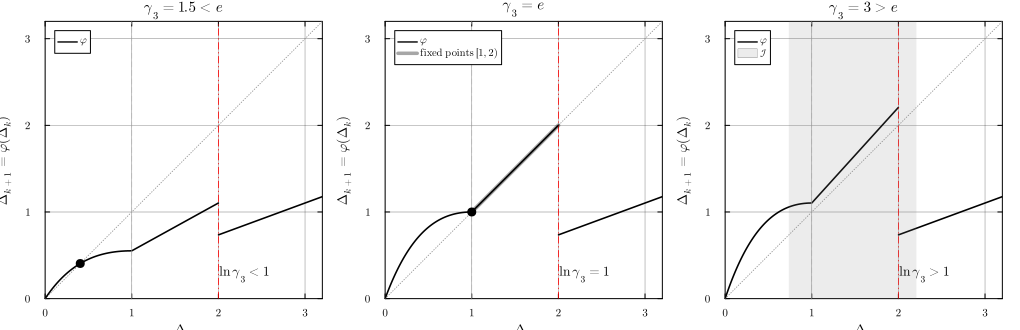

✓ wrote fig6_phi_map.pdf


In [20]:
# ---------------------------------------------------------------
# The map φ of eqn:example grad map, in the three regimes
# ---------------------------------------------------------------
φ(Δ, γ3) = Δ ≥ 2 ? Δ * exp(-1) : Δ * exp(log(γ3) - min(1.0, Δ))

const ΦCASES = [(1.5, L"\gamma_3 = 1.5 < e", L"\ln\gamma_3 < 1"),
                (ℯ,   L"\gamma_3 = e",       L"\ln\gamma_3 = 1"),
                (3.0, L"\gamma_3 = 3 > e",   L"\ln\gamma_3 > 1")]

Δgrid = range(1e-3, 3.2; length = 1200)

φplots = Plots.Plot[]
for (γ3, ttl, sub) in ΦCASES
    ℓ = log(γ3)
    p = plot(xlabel = L"\Delta_k", ylabel = L"\Delta_{k+1} = \varphi(\Delta_k)",
             title = ttl, titlefontsize = 10, legend = :topleft,
             xlims = (0, 3.2), ylims = (0, 3.2), aspect_ratio = :equal)

    # diagonal: fixed points are the crossings
    plot!(p, Δgrid, Δgrid; color = :gray60, linestyle = :dot, linewidth = 0.9, label = "")

    # the map, split at the jump Δ = 2 so no spurious vertical segment is drawn
    lo = filter(<(2.0), Δgrid)
    hi = filter(≥(2.0), Δgrid)
    plot!(p, lo, φ.(lo, γ3); color = :black, linewidth = 1.6, label = L"\varphi")
    plot!(p, hi, φ.(hi, γ3); color = :black, linewidth = 1.6, label = "")

    # threshold Δ = 2 and the kink at Δ = 1
    vline!(p, [2.0]; color = :red, linestyle = :dashdot, linewidth = 0.8, label = "")
    vline!(p, [1.0]; color = :gray70, linestyle = :dash, linewidth = 0.6, label = "")

    if γ3 < ℯ                      # unique attracting fixed point ln γ₃
        scatter!(p, [ℓ], [ℓ]; color = :black, markersize = 5, label = "")
    elseif γ3 ≈ ℯ                  # a whole segment of fixed points on [1,2)
        plot!(p, [1.0, 2.0], [1.0, 2.0]; color = :black, linewidth = 4, alpha = 0.35,
              label = L"\mathrm{fixed\ points}\ [1,2)")
        scatter!(p, [1.0], [1.0]; color = :black, markersize = 5, label = "")
    else                           # invariant band [2/e, 2γ₃/e]
        vspan!(p, [2/ℯ, 2γ3/ℯ]; color = :gray, alpha = 0.15, label = L"\mathcal{I}")
    end

    annotate!(p, 2.3, 0.28, text(sub, 9, :black))
    push!(φplots, p)
end

pφ = plot(φplots...; layout = (1, 3), size = (3 * 340, 330), legendfontsize = 7)
display(pφ)
savefig(pφ, "fig6_phi_map.pdf")
println("✓ wrote fig6_phi_map.pdf")

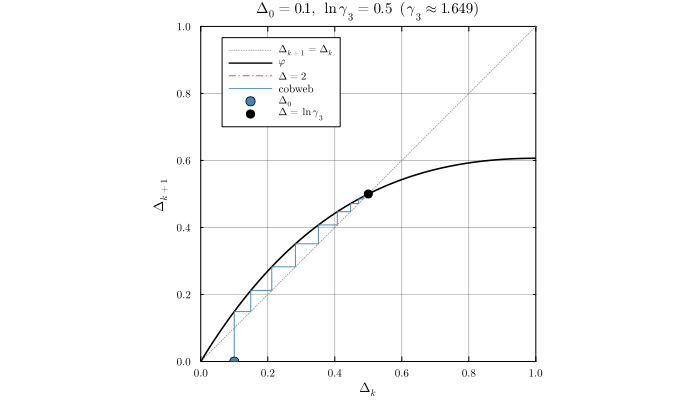

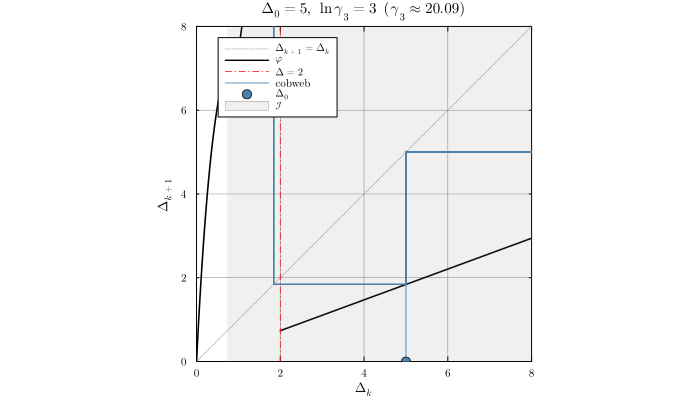

✓ wrote fig7a_cobweb_converge.pdf and fig7b_cobweb_oscillate.pdf


In [21]:
# ---------------------------------------------------------------
# Cobweb (staircase / spiral) diagrams for the map φ
# ---------------------------------------------------------------
φ(Δ, γ3) = Δ ≥ 2 ? Δ * exp(-1) : Δ * exp(log(γ3) - min(1.0, Δ))

"Cobweb path (x,y) for n steps of φ started at Δ0."
function cobweb(Δ0, γ3, n)
    xs, ys = [Δ0], [0.0]
    Δ = Δ0
    for _ in 1:n
        Δn = φ(Δ, γ3)
        push!(xs, Δ);  push!(ys, Δn)   # vertical: up to the curve
        push!(xs, Δn); push!(ys, Δn)   # horizontal: across to the diagonal
        Δ = Δn
    end
    return xs, ys
end

function cobweb_plot(Δ0, lnγ3, n; xmax = nothing, title = "")
    γ3 = exp(lnγ3)
    xmax = isnothing(xmax) ? 1.15 * max(Δ0, 2.2) : xmax
    grid = range(1e-4, xmax; length = 1500)

    p = plot(xlabel = L"\Delta_k", ylabel = L"\Delta_{k+1}", title = title,
             titlefontsize = 10, legend = :topleft, aspect_ratio = :equal,
             xlims = (0, xmax), ylims = (0, xmax))

    plot!(p, grid, grid; color = :gray60, linestyle = :dot, linewidth = 0.9,
          label = L"\Delta_{k+1} = \Delta_k")

    lo = filter(<(2.0), grid); hi = filter(≥(2.0), grid)
    plot!(p, lo, φ.(lo, γ3); color = :black, linewidth = 1.6, label = L"\varphi")
    isempty(hi) || plot!(p, hi, φ.(hi, γ3); color = :black, linewidth = 1.6, label = "")

    vline!(p, [2.0]; color = :red, linestyle = :dashdot, linewidth = 0.8, label = L"\Delta = 2")

    xs, ys = cobweb(Δ0, γ3, n)
    plot!(p, xs, ys; color = :steelblue, linewidth = 1.1, alpha = 0.85, label = "cobweb")
    scatter!(p, [Δ0], [0.0]; color = :steelblue, markersize = 5, label = L"\Delta_0")

    if lnγ3 < 1
        scatter!(p, [lnγ3], [lnγ3]; color = :black, markersize = 5,
                 label = L"\Delta = \ln\gamma_3")
    else
        vspan!(p, [2/ℯ, 2γ3/ℯ]; color = :gray, alpha = 0.12, label = L"\mathcal{I}")
    end
    return p
end

p_a = cobweb_plot(0.1, 0.5, 40;xmax = 1.0,
                  title = L"\Delta_0 = 0.1,\ \ln\gamma_3 = 0.5\ \ (\gamma_3 \approx 1.649)")
p_b = cobweb_plot(5.0, 3.0, 40; xmax = 8.0,
                  title = L"\Delta_0 = 5,\ \ln\gamma_3 = 3\ \ (\gamma_3 \approx 20.09)")

display(p_a); display(p_b)
savefig(p_a, "fig7a_cobweb_converge.pdf")
savefig(p_b, "fig7b_cobweb_oscillate.pdf")
println("✓ wrote fig7a_cobweb_converge.pdf and fig7b_cobweb_oscillate.pdf")

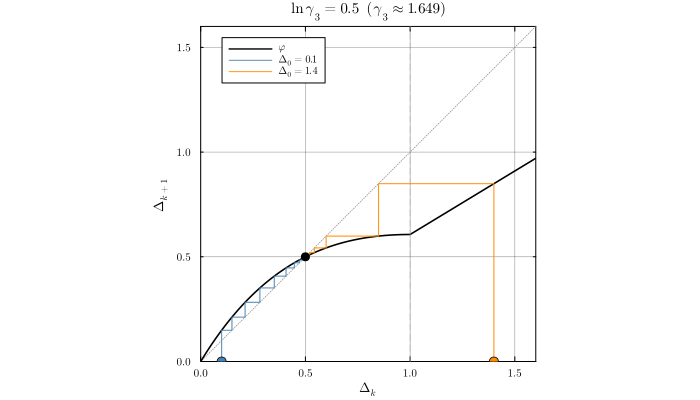

✓ wrote fig7_cobweb_two_starts.pdf


In [22]:
# ---------------------------------------------------------------
# Two cobwebs on one axis: ln γ₃ = 0.5, Δ₀ = 0.1 (below) and 1.4 (above)
# ---------------------------------------------------------------
φ(Δ, γ3) = Δ ≥ 2 ? Δ * exp(-1) : Δ * exp(log(γ3) - min(1.0, Δ))

function cobweb(Δ0, γ3, n)
    xs, ys = [Δ0], [0.0]
    Δ = Δ0
    for _ in 1:n
        Δn = φ(Δ, γ3)
        push!(xs, Δ);  push!(ys, Δn)
        push!(xs, Δn); push!(ys, Δn)
        Δ = Δn
    end
    return xs, ys
end

lnγ3 = 0.5
γ3   = exp(lnγ3)
xmax = 1.6
grid = range(1e-4, xmax; length = 1500)

pcw = plot(xlabel = L"\Delta_k", ylabel = L"\Delta_{k+1}",
           title = L"\ln\gamma_3 = 0.5\ \ (\gamma_3 \approx 1.649)",
           titlefontsize = 10, legend = :topleft, aspect_ratio = :equal,
           xlims = (0, xmax), ylims = (0, xmax))

plot!(pcw, grid, grid; color = :gray60, linestyle = :dot, linewidth = 0.9,
      label = "")
plot!(pcw, grid, φ.(grid, γ3); color = :black, linewidth = 1.6, label = L"\varphi")
vline!(pcw, [1.0]; color = :gray70, linestyle = :dash, linewidth = 0.6, label = "")

# --- trajectory 1: starts below the fixed point, climbs ---
xs1, ys1 = cobweb(0.1, γ3, 40)
plot!(pcw, xs1, ys1; color = :steelblue, linewidth = 1.1, alpha = 0.9,
      label = L"\Delta_0 = 0.1")
scatter!(pcw, [0.1], [0.0]; color = :steelblue, markersize = 5, label = "")

# --- trajectory 2: starts above the fixed point, descends ---
xs2, ys2 = cobweb(1.4, γ3, 40)
plot!(pcw, xs2, ys2; color = :darkorange, linewidth = 1.1, alpha = 0.9,
      label = L"\Delta_0 = 1.4")
scatter!(pcw, [1.4], [0.0]; color = :darkorange, markersize = 5, label = "")

# --- the common limit ---
scatter!(pcw, [lnγ3], [lnγ3]; color = :black, markersize = 5,
         label = "")

display(pcw)
savefig(pcw, "fig7_cobweb_two_starts.pdf")
println("✓ wrote fig7_cobweb_two_starts.pdf")

uncapped: Δ₄₉₉ = 0.693147   (settles at ln γ₃ = 0.693147)
capped:   Δ₄₉₉ = 1.993754e-03   (harmonic decay, → 0)


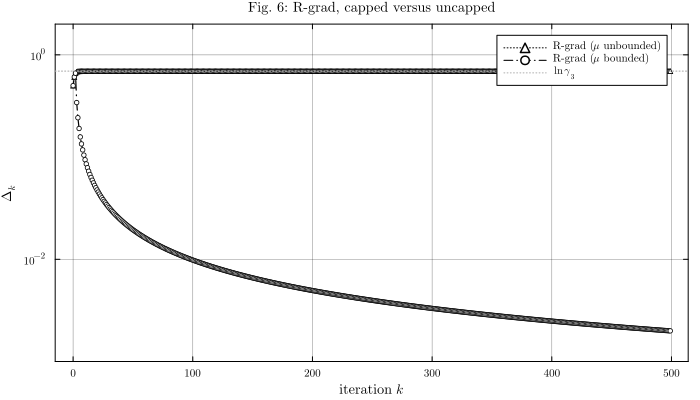

In [23]:
Rgrad_bounded = run_example(mk_gradcapped(); N = 500)
Rgrad         = run_example(mk_grad();       N = 500)

ks500 = 0:499
p6 = plot(xlabel = L"iteration $k$", ylabel = L"\Delta_k", yscale = :log10,
          legend = :topright, title = "Fig. 6: R-grad, capped versus uncapped",
          ylims = (1e-3, 2))
plot!(p6, ks500, Rgrad[1],         label = LBL_GU, c = :black, ls = :dot,
      m = :utriangle, markercolor = :white)
plot!(p6, ks500, Rgrad_bounded[1], label = LBL_GB, c = :black, ls = :dashdot,
      m = :circle, markercolor = :white)
hline!(p6, [log(G3)], label = L"\ln\gamma_3", c = :gray70, ls = :dot)
savefig(p6, "fig6_rgrad_capped_vs_not.pdf")

@printf("uncapped: Δ₄₉₉ = %.6f   (settles at ln γ₃ = %.6f)\n", Rgrad[1][end], log(G3))
@printf("capped:   Δ₄₉₉ = %.6e   (harmonic decay, → 0)\n", Rgrad_bounded[1][end])
p6

In [24]:
# 700, not 1000: x_k = k for R-delta, and e^{-x} underflows to zero past x ≈ 745.
# Beyond that f, ared and pred are all exactly 0, ρ becomes 0/0 → -Inf, and the run
# starts rejecting steps for a reason that belongs to floating point rather than to
# the mechanism. The qualitative claim (Σ Δ_k = ∞ for every rule) is unaffected.
const NSUM = 700

700

In [25]:
println("Sums over at most $NSUM iterations (global regime, f(x) = e^{-x}):")
@printf("%-24s %8s %14s %14s\n", "rule", "N reached", "Σ Δ_k", "Σ Δ_k²")

sum_rows = Vector{String}[]
for (nm, tex, mk) in [("R-delta", raw"R-delta", mk_delta),
                      ("R-step",  raw"R-step",  mk_step),
                      ("R-DFO",   raw"R-DFO",   mk_dfo),
                      ("R-grad (μ bounded)",   raw"R-grad ($\mu$ bounded)",   mk_gradcapped),
                      ("R-grad (μ unbounded)", raw"R-grad ($\mu$ unbounded)", mk_grad)]
    Δ = run_example(mk(); N = NSUM)[1]
    n = length(Δ)                      # what the run actually produced, not NSUM
    sΔ, sΔ2 = sum(Δ), sum(abs2, Δ)
    @printf("%-24s %8d %14.4g %14.4g\n", nm, n, sΔ, sΔ2)
    push!(sum_rows, [tex, string(n), sci(sΔ; d = 3), sci(sΔ2; d = 3)])
end
println("\nΣ Δ_k = +∞ for EVERY rule: the algorithm must travel an infinite distance")
println("to drive the gradient to zero on f(x) = e^{-x}.  For the anchored rules the")
println("divergence is only logarithmic (harmonic decay), and Σ Δ_k² converges.")
println("\nThe N column is not the same for every rule. A run ends early when the")
println("radius collapses to where f(x) - f(x+s) is rounding, and the sum is then")
println("over the iterations that happened, not over NSUM.")

open(io -> latex_table(io, [raw"Rule", raw"$N$", raw"$\sum_{k<N}\Delta_k$", raw"$\sum_{k<N}\Delta_k^2$"],
                       sum_rows;
                       align   = "lrrr",
                       caption = raw"Partial sums on $f(x)=e^{-x}$, $x_0=0$, over at most " *
                                 string(NSUM) * raw" iterations. $N$ is the number each run " *
                                 raw"actually produced and is not the same for every rule: a " *
                                 raw"run stops early once the radius has collapsed to where " *
                                 raw"$f(x)-f(x+s)$ is pure rounding, so each sum is over its " *
                                 raw"own $N$ and the rows are not directly comparable as " *
                                 raw"totals. Every rule has $\sum_k\Delta_k=+\infty$ in the " *
                                 raw"limit: the iterates must travel an infinite distance to " *
                                 raw"drive the gradient to zero. For the criticality-anchored " *
                                 raw"rules (R-DFO and R-grad with $\mu$ bounded) the radius " *
                                 raw"decays harmonically, so the divergence is only " *
                                 raw"logarithmic and $\sum_k\Delta_k^2$ converges. For " *
                                 raw"R-delta the radius overflows double precision before " *
                                 raw"its $N$ is reached, so the $+\infty$ entry is an " *
                                 raw"overflow rather than a proof of divergence (though the " *
                                 raw"series does diverge). A partial sum over a finite run " *
                                 raw"settles neither convergence nor divergence.",
                       label   = "tab: sums exponential"),
     "tab_sums.txt", "w")

println("\n✓ wrote tab_sums.txt")

Sums over at most 700 iterations (global regime, f(x) = e^{-x}):
rule                     N reached          Σ Δ_k         Σ Δ_k²
R-delta                       607      1.172e+59      3.53e+117
R-step                        393          797.6           1881
R-DFO                         700            5.9           1.43
R-grad (μ bounded)            700          7.248           1.43
R-grad (μ unbounded)          539          373.3          258.6

Σ Δ_k = +∞ for EVERY rule: the algorithm must travel an infinite distance
to drive the gradient to zero on f(x) = e^{-x}.  For the anchored rules the
divergence is only logarithmic (harmonic decay), and Σ Δ_k² converges.

The N column is not the same for every rule. A run ends early when the
radius collapses to where f(x) - f(x+s) is rounding, and the sum is then
over the iterations that happened, not over NSUM.

✓ wrote tab_sums.txt


---
## What this notebook checks about the package

Every figure and number above is produced by `tr_solve`, so the notebook doubles as an
end-to-end test of the solver against results derived on paper:

| assertion | what it pins down |
|:--|:--|
| $s_k = \min\{1,\Delta_k\}$, `active` flag, $\rho_k = \rho_{\text{exact}}(s_k)$ | `ExactHessian` + `SteihaugCG` on both sides of the boundary, and the ratio |
| $\Delta_{10} = 1024$, $\Delta_{29} = 2^{29}$ for `RDelta` | the three-branch update, and that $\eta_2$ is read correctly |
| `RStep` locks at $\gamma_3\lvert s\rvert = 2$ | the step anchor, and `Δmin` not interfering |
| $\Delta_{k+1} = \Delta_k e^{-\Delta_k}$ to ten digits | `RGradCapped` once $\mu$ saturates — and the step and ratio feeding it |
| $k\Delta_k \to 0.9939$ at $k = 399$ | harmonic decay, hence $\sum\Delta_k^2 < \infty$ |
| trajectories follow $\varphi$ on **both** sides of $\Delta = 2$ | the four-branch form *and* the half-test guard |
| `half_test = false` expands where `true` does not | the guard is load-bearing, not cosmetic |
| $\gamma_3 < e$ ⟹ fixed point $\ln\gamma_3$; $\gamma_3 \ge e$ ⟹ $\liminf\Delta_k \ge 2/e$ | the whole bifurcation, which no unit test states |
| `asymptotic_regime` matches the observed behaviour | the three-way classification the experiment scripts group by |
| `ScaledIdentity(c)` reproduces $x_{k+1} = (1-1/c)x_k$ | the diagnostic model, and the accept/reject path |

The last three are the ones a unit test would not catch. The $\gamma_3$ versus $e$ boundary is
an *emergent* property of the four-branch recurrence — nobody coded it — so if a future edit
moved the branch conditions, the assertions here would fail while every individual branch
still looked correct in isolation.

If a cell raises, prefer the notebook over the package: these results are derived analytically
in the surrounding text and the arithmetic is checkable by hand.

### Two deliberate settings

- **`tol = 1e-300`.** The runs must not stop early; we want `N` iterations of the recurrence,
  not convergence. Every run therefore ends `:max_iter`, which here is the intended outcome.
- **`NSUM = 700`.** Beyond $x \approx 745$, $e^{-x}$ underflows to zero, so $f$, `ared` and
  `pred` all vanish, $\rho$ becomes $0/0 \to -\infty$, and the run rejects steps for a reason
  belonging to floating point rather than to the mechanism. `R-delta` advances $x_k$ by one
  per iteration, so it reaches that wall first.